# Credit Card Fraud Detection
- Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Goal: build a model that reliably catches fraudulent transactions despite them being extremely rare.

In [2]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

### Data Collection

In [ ]:
#Load Dataset
df = pd.read_csv('creditcard.csv')
df['Classes'] = df['Class'].map({0: 'Not Fraud', 1: 'Fraud'})

print(df.head())
print(df.info())
print(df.describe())

print(df['Classes'].value_counts())  #Check class balance

#Check for nulls
print("Total missing values:", df.isnull().sum().sum())

#Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

df['Classes'].value_counts(normalize=True) * 100

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V22       V23       V24       V25       V26  \
0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
2  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642 -0.139097   
3  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.221929   
4 -0.270533  0.817739  ...  0.798278 -0.137458  0.141267 -0.206010  0.502292   

        V27       V28  Amount  C

Classes
Not Fraud    99.827251
Fraud         0.172749
Name: proportion, dtype: float64

### Preprocessing

In [5]:
#Drop duplicates
df = df.drop_duplicates()

print("New shape:", df.shape)
print("\nClass distribution after dropping duplicates:")
print(df['Classes'].value_counts())
print(df['Classes'].value_counts(normalize=True) * 100)

New shape: (283726, 32)

Class distribution after dropping duplicates:
Classes
Not Fraud    283253
Fraud           473
Name: count, dtype: int64
Classes
Not Fraud    99.83329
Fraud         0.16671
Name: proportion, dtype: float64


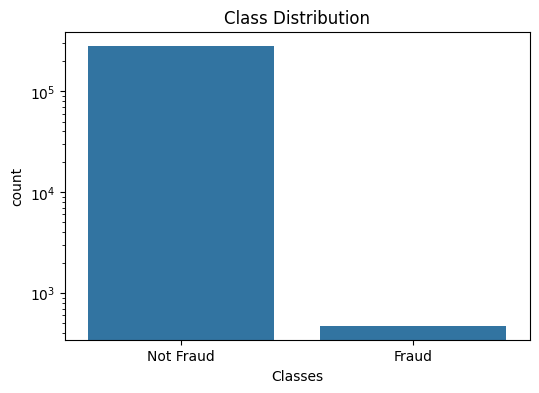

In [6]:
#Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Classes')
plt.title('Class Distribution')
plt.yscale('log')  #log scale needed- fraud bar would be invisible otherwise
plt.show()

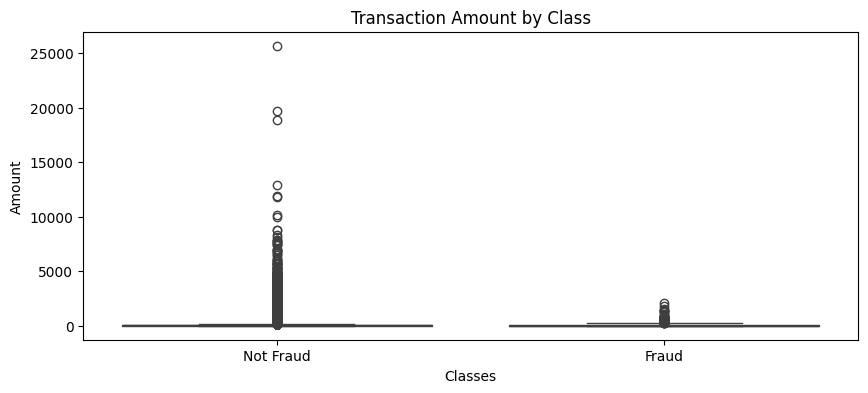

              count        mean         std  min   25%    50%     75%  \
Classes                                                                 
Fraud         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   
Not Fraud  283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46   

                max  
Classes              
Fraud       2125.87  
Not Fraud  25691.16  


In [7]:
#Amount distribution: fraud vs not fraud
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='Classes', y='Amount')
plt.title('Transaction Amount by Class')
plt.show()

print(df.groupby('Classes')['Amount'].describe())

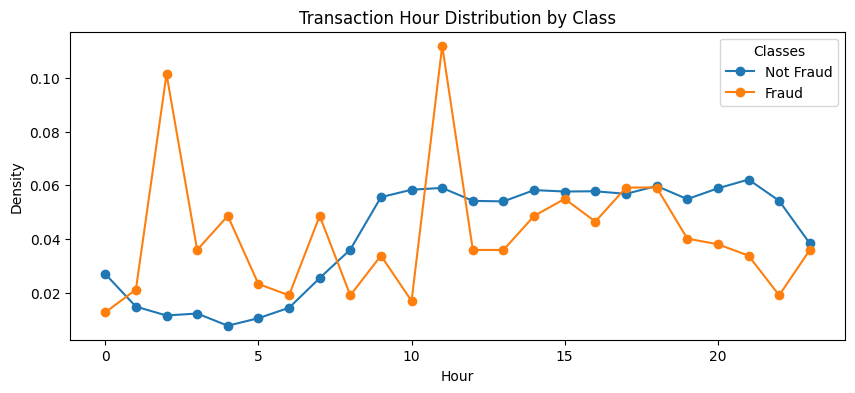

In [8]:
df['Hour'] = (df['Time'] % 86400) // 3600

plt.figure(figsize=(10,4))
for cls in ['Not Fraud', 'Fraud']:
    subset = df[df['Classes'] == cls]
    counts, bins = np.histogram(subset['Hour'], bins=24, range=(0,24), density=True)
    plt.plot(bins[:-1], counts, marker='o', label=cls)
plt.xlabel('Hour')
plt.ylabel('Density')
plt.title('Transaction Hour Distribution by Class')
plt.legend(title='Classes')
plt.show()

In [9]:
fraud_hours = df[df['Classes']=='Fraud']['Hour']
print("Most common fraud hours:", fraud_hours.value_counts().head())

Most common fraud hours: Hour
11.0    53
2.0     48
17.0    28
18.0    28
15.0    26
Name: count, dtype: int64


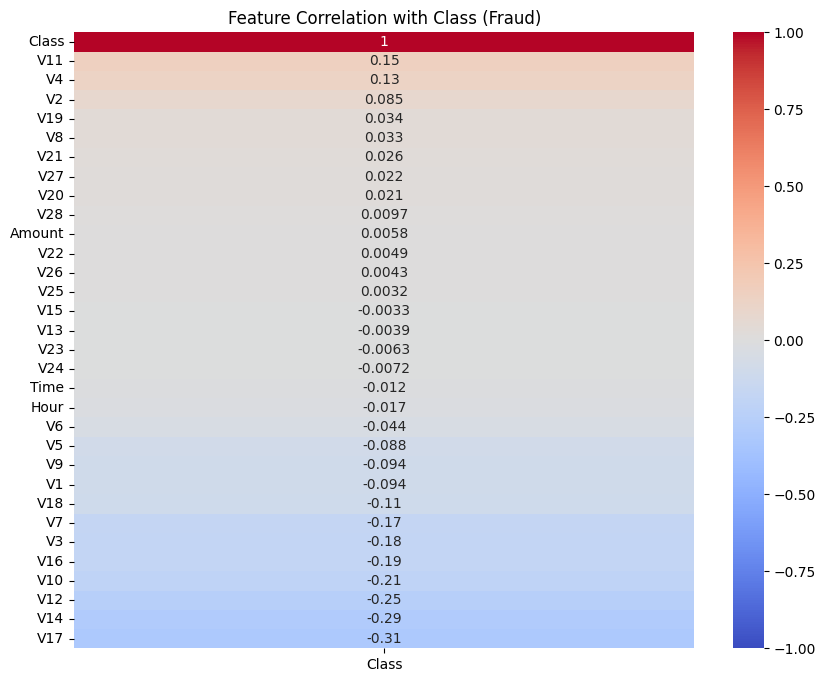

In [10]:
#Correlation with Class
corr = df.drop(columns=['Classes']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Class (Fraud)')
plt.show()

### Feature Scaling

In [ ]:
#Log-transform Amount first (reduces skew)
df['Amount_log'] = np.log1p(df['Amount'])  #log1p = log(1+x), handles 0 values safely, new column='Amount_log'

#Scale Amount_log and Time
scaler = StandardScaler()
df[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(df[['Amount_log', 'Time']])

print(df[['Amount', 'Amount_log', 'Amount_scaled', 'Time', 'Time_scaled']].head())

   Amount  Amount_log  Amount_scaled  Time  Time_scaled
0  149.62    5.014760       1.123062   0.0    -1.996823
1    2.69    1.305626      -1.115298   0.0    -1.996823
2  378.66    5.939276       1.680981   1.0    -1.996802
3  123.50    4.824306       1.008128   1.0    -1.996802
4   69.99    4.262539       0.669117   2.0    -1.996781


In [ ]:
from sklearn.model_selection import train_test_split

#Features and target
X = df.drop(columns=['Class', 'Classes', 'Amount', 'Amount_log', 'Amount_scaled', 'Time', 'Time_scaled'])
y = df['Class']

#Add back the log-transformed (but not yet scaled) columns
X['Amount_log'] = df['Amount_log']
X['Time'] = df['Time']

#Stratified split (keeps the same fraud/not-fraud ratio in train/test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Fit scaler on training data
scaler = StandardScaler()
X_train[['Amount_scaled', 'Time_scaled']] = scaler.fit_transform(X_train[['Amount_log', 'Time']]) #calculates mean/std from training data only, then applies it to train.s
X_test[['Amount_scaled', 'Time_scaled']] = scaler.transform(X_test[['Amount_log', 'Time']]) #reuses that SAME mean/std, applies it to test data.

X_train = X_train.drop(columns=['Amount_log', 'Time'])
X_test = X_test.drop(columns=['Amount_log', 'Time'])

print("Train shape:", X_train.shape, "Test shape:", y_train.shape)
print("Train fraud ratio:", y_train.value_counts(normalize=True))
print("Test fraud ratio:", y_test.value_counts(normalize=True))

Train shape: (226980, 31) Test shape: (226980,)
Train fraud ratio: Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64
Test fraud ratio: Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


Logistic Regression before applying smote

Using Class weight parameter: https://www.geeksforgeeks.org/machine-learning/how-does-the-classweight-parameter-in-scikit-learn-work/

In [32]:
class_weight = {0: 1, 1: 30}  # much gentler than the ~300x 'balanced' would calculate
model = LogisticRegression(solver='lbfgs', max_iter=200, class_weight=class_weight)
model.fit(X_train, y_train)

y_pred_cw2 = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_cw2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cw2, target_names=['Not Fraud', 'Fraud']))

Accuracy: 0.9988721672012124

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.63      0.79      0.70        95

    accuracy                           1.00     56746
   macro avg       0.81      0.89      0.85     56746
weighted avg       1.00      1.00      1.00     56746



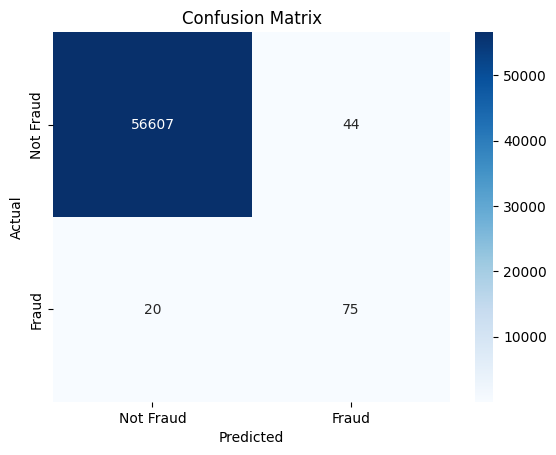

In [33]:
cm = confusion_matrix(y_test, y_pred_cw2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### SMOTE (training data only)
reference: https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

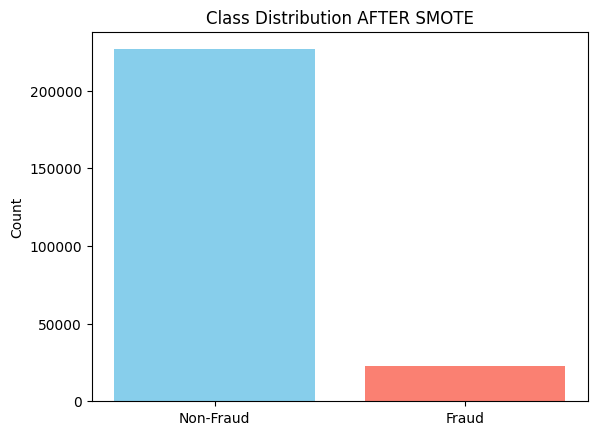

In [24]:
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
model = LogisticRegression(solver='lbfgs', max_iter=200)
model.fit(X_train_sm, y_train_sm)

y_pred_sm = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sm, target_names=['Not Fraud', 'Fraud']))

Accuracy: 0.9975504881401333

Classification Report:
               precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56651
       Fraud       0.39      0.81      0.53        95

    accuracy                           1.00     56746
   macro avg       0.69      0.90      0.76     56746
weighted avg       1.00      1.00      1.00     56746



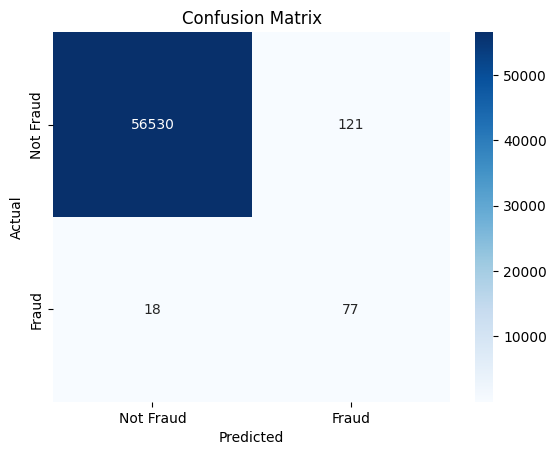

In [28]:
cm = confusion_matrix(y_test, y_pred_sm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()